In [7]:
import zipfile

with zipfile.ZipFile("/content/archive (20).zip", "r") as zip_ref:
    zip_ref.extractall("/content/")

In [8]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("TensorFlow Version :", tf.__version__)

# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow Version : 2.20.0


In [9]:
# ==========================================================
# Load FER2013 Dataset for ResNet50
# ==========================================================

# Dataset Paths
train_dir = "/content/train"
test_dir = "/content/test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# ----------------------------------------------------------
# Training Dataset
# ----------------------------------------------------------

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    color_mode="rgb",
    shuffle=True,
    seed=SEED
)

# ----------------------------------------------------------
# Testing Dataset
# ----------------------------------------------------------

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    color_mode="rgb",
    shuffle=False
)

# ----------------------------------------------------------
# Class Names
# ----------------------------------------------------------

class_names = train_dataset.class_names
NUM_CLASSES = len(class_names)

print("\nClasses:", class_names)
print("Number of Classes:", NUM_CLASSES)

# ----------------------------------------------------------
# ImageNet Preprocessing
# ----------------------------------------------------------

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.map(
    lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y),
    num_parallel_calls=AUTOTUNE
)

test_dataset = test_dataset.map(
    lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y),
    num_parallel_calls=AUTOTUNE
)

train_dataset = train_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

print("\nDataset Loaded Successfully!")

# ----------------------------------------------------------
# Verify Dataset
# ----------------------------------------------------------

for images, labels in train_dataset.take(1):
    print("\nImage Batch Shape :", images.shape)
    print("Label Batch Shape :", labels.shape)

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of Classes: 7

Dataset Loaded Successfully!

Image Batch Shape : (32, 224, 224, 3)
Label Batch Shape : (32,)


In [10]:
# ==========================================================
# Build Pretrained ResNet50 Model
# ==========================================================

# Load ImageNet pretrained ResNet50
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the pretrained backbone
base_model.trainable = False

# Build custom classifier
inputs = keras.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(512, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs)

print("="*60)
print("Pretrained ResNet50 Model")
print("="*60)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Pretrained ResNet50 Model


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,772,999 (94.50 MB)

 Trainable params: 1,183,751 (4.52 MB)

 Non-trainable params: 23,589,248 (89.99 MB)

In [11]:
# ==========================================================
# Compile Model
# ==========================================================

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ==========================================================
# Callbacks
# ==========================================================

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# ==========================================================
# Train Only Custom Classifier
# ==========================================================

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 140s 138ms/step - accuracy: 0.4413 - loss: 1.5781 - val_accuracy: 0.5213 - val_loss: 1.2673 - learning_rate: 0.0010
Epoch 2/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 114s 126ms/step - accuracy: 0.5122 - loss: 1.2953 - val_accuracy: 0.5436 - val_loss: 1.2093 - learning_rate: 0.0010
Epoch 3/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 114s 126ms/step - accuracy: 0.5339 - loss: 1.2378 - val_accuracy: 0.5510 - val_loss: 1.1949 - learning_rate: 0.0010
Epoch 4/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 119s 132ms/step - accuracy: 0.5445 - loss: 1.2030 - val_accuracy: 0.5521 - val_loss: 1.1831 - learning_rate: 0.0010
Epoch 5/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 158s 150ms/step - accuracy: 0.5600 - loss: 1.1718 - val_accuracy: 0.5610 - val_loss: 1.1677 - learning_rate: 0.0010
Epoch 6/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 115s 128ms/step - accuracy: 0.5712 - loss: 1.1459 - val_accuracy: 0.5627 - val_loss: 1.1740 - learning_rate: 0.0010
Epoch 7/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 114s 127ms/step - accura

In [12]:
# ==========================================================
# Fine-Tune ResNet50
# ==========================================================

# Unfreeze the ResNet50 backbone
base_model.trainable = True

# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

print("Trainable Layers:")

count = 0
for layer in base_model.layers:
    if layer.trainable:
        count += 1

print(count)

# ==========================================================
# Recompile with a Small Learning Rate
# ==========================================================

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ==========================================================
# Fine-Tune
# ==========================================================

history_finetune = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=3,
    callbacks=[early_stop, reduce_lr]
)

Trainable Layers:
30
Epoch 1/3
898/898 ━━━━━━━━━━━━━━━━━━━━ 189s 184ms/step - accuracy: 0.5529 - loss: 1.1973 - val_accuracy: 0.5889 - val_loss: 1.1078 - learning_rate: 1.0000e-05
Epoch 2/3
898/898 ━━━━━━━━━━━━━━━━━━━━ 150s 167ms/step - accuracy: 0.6471 - loss: 0.9531 - val_accuracy: 0.6108 - val_loss: 1.0611 - learning_rate: 1.0000e-05
Epoch 3/3
898/898 ━━━━━━━━━━━━━━━━━━━━ 150s 166ms/step - accuracy: 0.7116 - loss: 0.8023 - val_accuracy: 0.6199 - val_loss: 1.0515 - learning_rate: 1.0000e-05


In [13]:
# ==========================================================
# Model Evaluation
# ==========================================================

import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Predict on test dataset
y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ----------------------------------------------------------
# Performance Metrics
# ----------------------------------------------------------

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print("="*50)
print("ResNet50 Performance")
print("="*50)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

# ----------------------------------------------------------
# Classification Report
# ----------------------------------------------------------

print("\nClassification Report\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

ResNet50 Performance
Accuracy  : 0.6199
Precision : 0.6139
Recall    : 0.6199
F1 Score  : 0.6133

Classification Report

              precision    recall  f1-score   support

       angry       0.53      0.49      0.51       958
     disgust       0.73      0.49      0.58       111
        fear       0.53      0.37      0.44      1024
       happy       0.74      0.84      0.79      1774
     neutral       0.56      0.64      0.60      1233
         sad       0.51      0.51      0.51      1247
    surprise       0.76      0.76      0.76       831

    accuracy                           0.62      7178
   macro avg       0.62      0.59      0.60      7178
weighted avg       0.61      0.62      0.61      7178



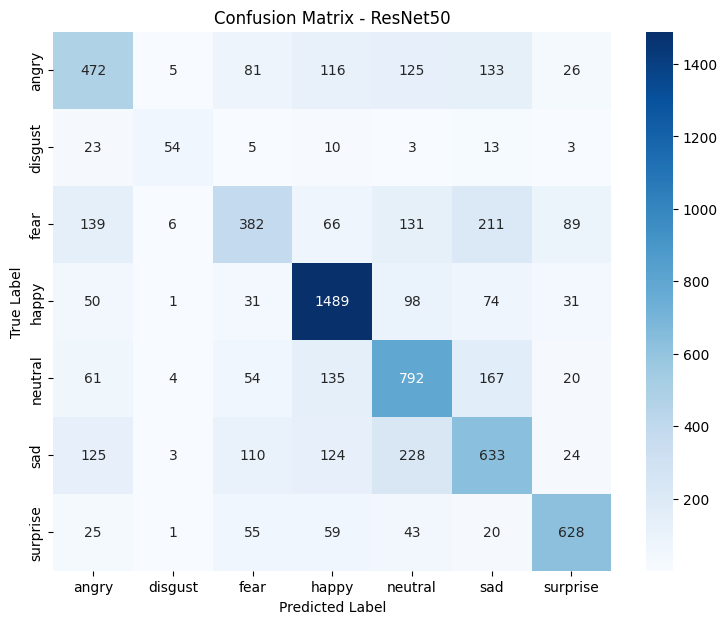

In [14]:
# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9,7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - ResNet50")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

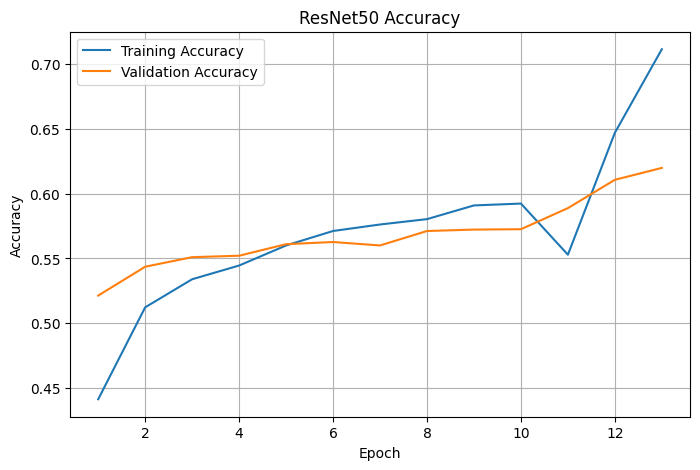

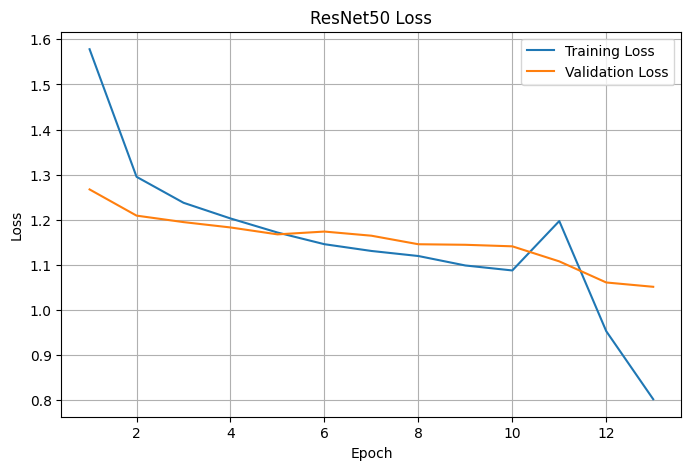

In [15]:
# ==========================================================
# Plot Accuracy & Loss Curves
# ==========================================================

# Combine Phase-1 and Phase-2 history
train_acc = history.history["accuracy"] + history_finetune.history["accuracy"]
val_acc = history.history["val_accuracy"] + history_finetune.history["val_accuracy"]

train_loss = history.history["loss"] + history_finetune.history["loss"]
val_loss = history.history["val_loss"] + history_finetune.history["val_loss"]

epochs = range(1, len(train_acc)+1)

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(epochs, train_acc, label="Training Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.title("ResNet50 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.title("ResNet50 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

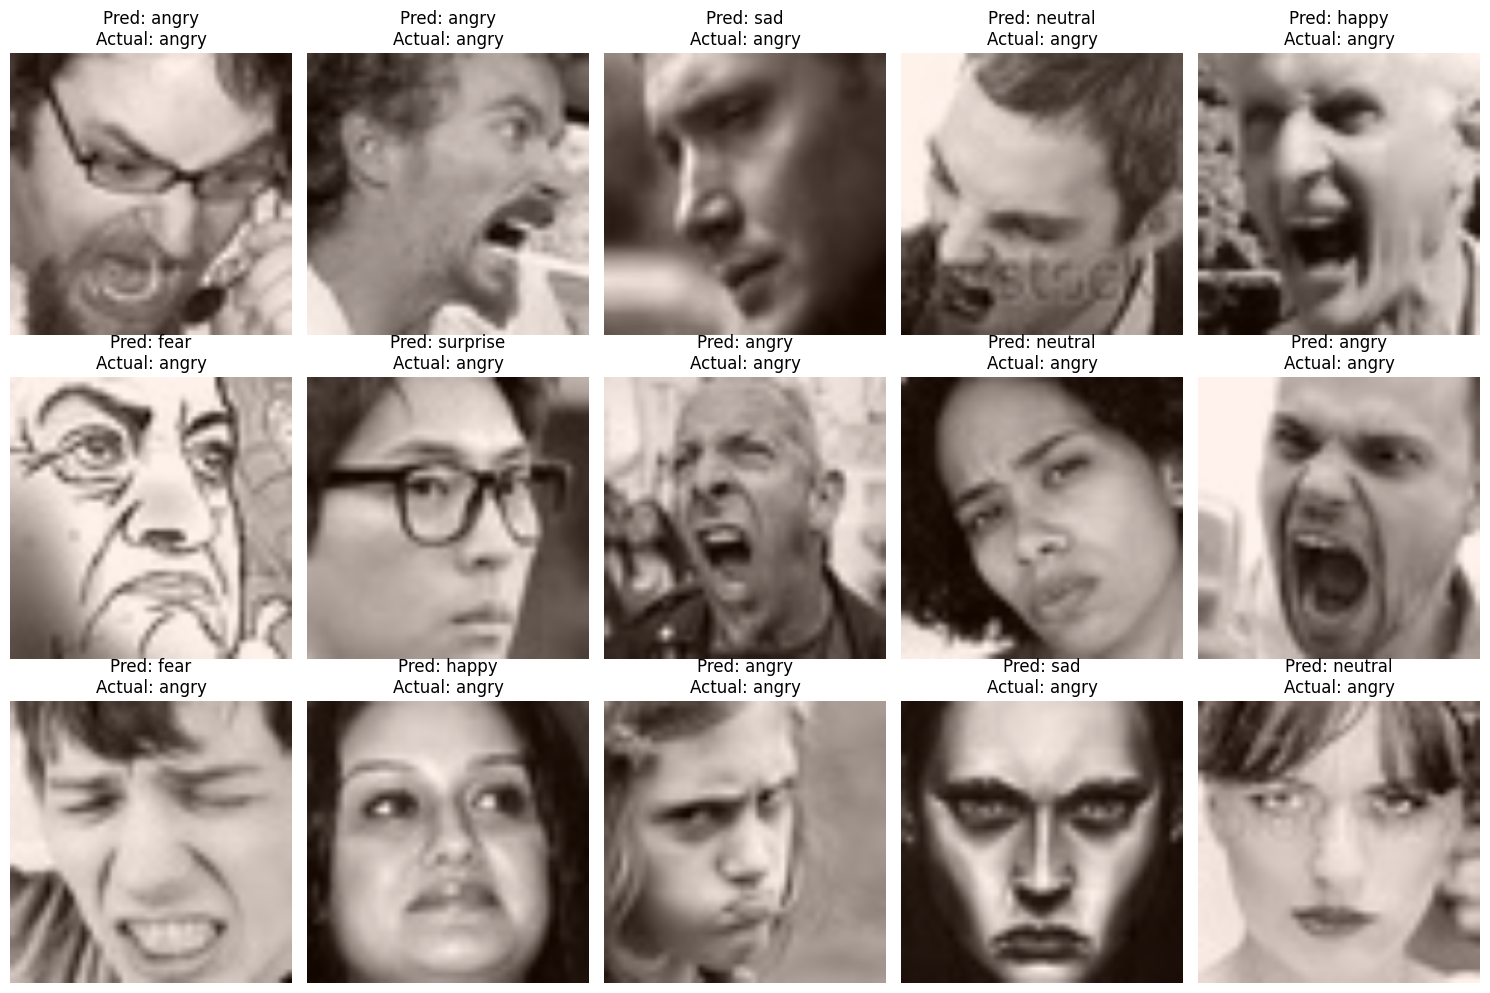

In [16]:
# ==========================================================
# Display Sample Predictions
# ==========================================================

plt.figure(figsize=(15,10))

images, labels = next(iter(test_dataset))

predictions = model.predict(images, verbose=0)

predicted_labels = np.argmax(predictions, axis=1)

for i in range(15):

    plt.subplot(3,5,i+1)

    img = images[i].numpy()

    # Reverse ImageNet preprocessing for display
    img = img - np.min(img)
    img = img / np.max(img)

    plt.imshow(img.astype("float32"))

    plt.title(
        f"Pred: {class_names[predicted_labels[i]]}\n"
        f"Actual: {class_names[labels[i].numpy()]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
# ==========================================================
# Save Trained Model
# ==========================================================

model.save("resnet50.keras")

print("Model saved successfully as resnet50.keras")

Model saved successfully as resnet50.keras
